In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import os
os.chdir("/Users/AlanHDLR/Desktop")
import pandas as pd

wine = pd.read_csv("wine-clustering.csv") # Cargar la base de datos de IRIS
wine

C:\Users\AlanHDLR\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\AlanHDLR\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [13]:
# Normalizamos los datos 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
wine_scaled = scaler.fit_transform(wine)

In [5]:
# Definir el número de vecinos
k = 5
# Definir punto a  relacionar
test_data = pd.DataFrame({
    'Alcohol': [14],'Malic_Acid': [2],'Ash': [2.5],'Ash_Alcanity': [16],'Magnesium': [115],
    'Total_Phenols': [3],'Flavanoids': [2.5],'Nonflavanoid_Phenols': [0.4],
    'Proanthocyanins': [2],'Color_Intensity': [9],'Hue': [1],'OD280': [3.5],'Proline': [800]
})
test_data_scaled = scaler.transform(test_data)

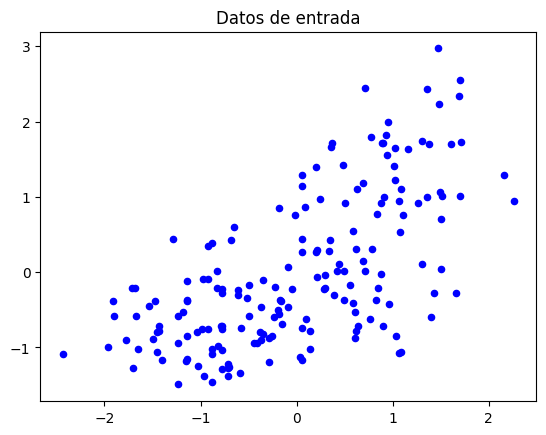

In [45]:
# Visualización de los puntos de la pblación
plt.figure()
plt.title("Datos de entrada")
plt.scatter(wine_scaled[:,0], wine_scaled[:,12], marker = 'o', s = 20, color ='blue')

In [23]:
# Ejecución del algortimo KNN
knn_model = NearestNeighbors(n_neighbors = k, algorithm = 'auto').fit(wine_scaled)
distances, indices = knn_model.kneighbors(test_data_scaled)

In [25]:
print("K vecinos mas cercanos: ")
for rank, index in enumerate(indices[0][:k], start = 1):
    print(str(rank) + "is", wine_scaled[index])

K vecinos mas cercanos: 
1is [ 0.69098501 -0.5622498  -0.20658837 -0.98942218  1.21177181  1.36981344
  1.2657313  -0.17609475  1.31248819  0.46367614 -0.03268321  1.08520045
  0.15319562]
2is [ 1.50625989 -0.57122643 -0.24314178 -0.95939368  1.28198515  1.44993001
  0.97458095 -0.82071924  0.76934211  0.57181864 -0.0765566   0.98632945
  0.71048202]
3is [ 1.1603857  -0.54429654 -0.352802   -0.62908019  0.57985175  0.93718392
  1.51672298 -0.33725087  0.85694632  1.66189499  0.71316437  0.68971646
  1.63398521]
4is [ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
  1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
  1.01300893]
5is [ 1.3086175  -0.63406285 -0.3162486  -1.04947918  1.84369188  1.1294637
  1.1452553  -0.98187536  0.891988    0.25604255  0.58154421  1.55130658
  0.10542821]


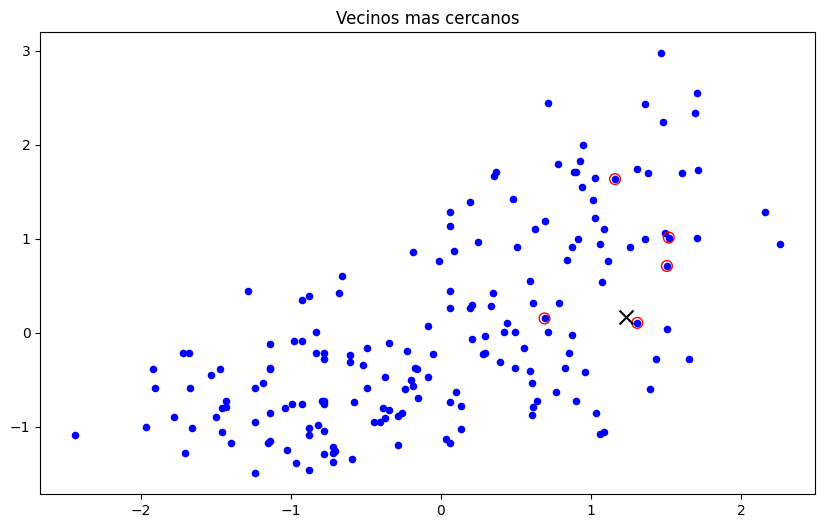

In [55]:
# Visuaalización de puntos asociados al punto de interés
plt.figure(figsize=(10, 6))
plt.title("Vecinos mas cercanos")
plt.scatter(wine_scaled[:,0], wine_scaled[:,12], marker = 'o', s = 20, color ='blue')
plt.scatter(wine_scaled[indices][0][:][:,0], wine_scaled[indices][0][:][:,12], marker = 'o', s= 60, color = 'red', facecolors = 'none')
plt.scatter(test_data_scaled[0,0], test_data_scaled[0,12], marker= 'x' , s = 100, color = 'black')
plt.show()

In [65]:
# Buscamos los valores de los 5 vecinos seleccionados mediante los indices
vecinos_originales = wine.iloc[indices[0]]

print("Valores originales de los 5 vecinos:")
print(vecinos_originales)

# Obtenemos el promedio de alcohol de los 5 vecinos:
promedio_alcohol = vecinos_originales['Alcohol'].mean()
print("El valor promedio de alcohol de los 5 vecinos es: ", promedio_alcohol, "%")

Valores originales de los 5 vecinos:
    Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
40    13.56        1.71  2.31          16.2        117           3.15   
56    14.22        1.70  2.30          16.3        118           3.20   
49    13.94        1.73  2.27          17.4        108           2.88   
0     14.23        1.71  2.43          15.6        127           2.80   
20    14.06        1.63  2.28          16.0        126           3.00   

    Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
40        3.29                  0.34             2.34             6.13  0.95   
56        3.00                  0.26             2.03             6.38  0.94   
49        3.54                  0.32             2.08             8.90  1.12   
0         3.06                  0.28             2.29             5.64  1.04   
20        3.17                  0.24             2.10             5.65  1.09   

    OD280  Proline  
40   3.38      795  
5

# Segundo ejercicio

In [69]:
my_basket = [['bread', 'butter', 'wine', 'bananas', 'coffee', 'carrots'],
    ['tomatoes', 'onions', 'cheese', 'milk', 'potatoes'],
    ['beer', 'chips', 'asparagus', 'salsa', 'milk', 'apples'],
    ['olive oil', 'bread', 'butter', 'tomatoes', 'steak', 'carrots'],
    ['tomatoes', 'onions', 'chips', 'wine', 'ketchup', 'orange juice'],
    ['bread', 'butter', 'beer', 'chips', 'milk'],
    ['butter', 'tomatoes', 'carrots', 'coffee', 'sugar'],
    ['tomatoes', 'onions', 'cheese', 'milk', 'potatoes'],
    ['bread', 'butter', 'ketchup', 'coffee', 'chicken wings'],
    ['butter', 'beer', 'chips', 'asparagus', 'apples'],
    ['tomatoes', 'onion', 'beer', 'chips', 'milk', 'coffee']]

<class 'list'>


In [71]:
# Utilizamos TransactionEncoder para analizar los datos, ya que no tenemos una 
# cantidad de cada uno, si no más bien solo sabemos si esta o no en la compra
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(my_basket).transform(my_basket)
basket_filtrado = pd.DataFrame(te_ary, columns=te.columns_).astype(int)
basket_filtrado

,apples,asparagus,bananas,beer,bread,butter,carrots,cheese,chicken wings,chips,...,olive oil,onion,onions,orange juice,potatoes,salsa,steak,sugar,tomatoes,wine
0,0,0,1,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,1,0
2,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,1,1,0,0,0,...,1,0,0,0,0,0,1,0,1,0
4,0,0,0,0,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,1,1
5,0,0,0,1,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,1,0
7,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,1,0
8,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9,1,1,0,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [73]:
# Codificación a binario de la base previa para identificar si un articulo se compro o no
def codificar(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

basket_codificado = basket_filtrado.map(codificar)
basket_codificado

,apples,asparagus,bananas,beer,bread,butter,carrots,cheese,chicken wings,chips,...,olive oil,onion,onions,orange juice,potatoes,salsa,steak,sugar,tomatoes,wine
0,0,0,1,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,1,0
2,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,1,1,0,0,0,...,1,0,0,0,0,0,1,0,1,0
4,0,0,0,0,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,1,1
5,0,0,0,1,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,1,0
7,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,1,0
8,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9,1,1,0,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [75]:
# Filtrado de aquellas trasnsacciones en donde se ha comprado más de un artículo
basket_filtrado = basket_codificado[(basket_codificado > 0).sum(axis = 1) >= 2]
basket_filtrado

,apples,asparagus,bananas,beer,bread,butter,carrots,cheese,chicken wings,chips,...,olive oil,onion,onions,orange juice,potatoes,salsa,steak,sugar,tomatoes,wine
0,0,0,1,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,1,0
2,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,1,1,0,0,0,...,1,0,0,0,0,0,1,0,1,0
4,0,0,0,0,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,1,1
5,0,0,0,1,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,1,0
7,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,1,0
8,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9,1,1,0,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [77]:
# Aplicación del algoritmo "a priori" para localizar los artículos frecuentemente comprados en la base de datos
from mlxtend.frequent_patterns import apriori

In [79]:
from mlxtend.frequent_patterns import apriori

# 1. Generamos los itemsets frecuentes
articulos_frecuentes = apriori(basket_filtrado, 
                               min_support = 0.2, 
                               use_colnames = True)

# 2. Ordenamos por soporte (los más vendidos primero) y reseteamos el índice
articulos_frecuentes = articulos_frecuentes.sort_values("support", ascending = False).reset_index(drop = True)

# 3. Creamos la columna 'length' (corregido) para saber cuántos productos hay en el set
articulos_frecuentes["length"] = articulos_frecuentes["itemsets"].apply(lambda x: len(x))

articulos_frecuentes

C:\Users\AlanHDLR\AppData\Roaming\Python\Python312\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets,length
0,0.545455,frozenset({tomatoes}),1
1,0.545455,frozenset({butter}),1
2,0.454545,frozenset({chips}),1
3,0.454545,frozenset({milk}),1
4,0.363636,frozenset({beer}),1
5,0.363636,"frozenset({butter, bread})",2
6,0.363636,frozenset({bread}),1
7,0.363636,"frozenset({beer, chips})",2
8,0.363636,frozenset({coffee}),1
9,0.272727,frozenset({onions}),1


In [81]:
from mlxtend.frequent_patterns import association_rules

In [83]:
association_rules(articulos_frecuentes, metric ="confidence",
                 min_threshold = 0.75).sort_values("confidence", ascending = False).reset_index(drop = True)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({bread}),frozenset({butter}),0.363636,0.545455,0.363636,1.0,1.833333,1.0,0.165289,inf,0.714286,0.666667,1.000000,0.833333
1,frozenset({beer}),frozenset({chips}),0.363636,0.454545,0.363636,1.0,2.200000,1.0,0.198347,inf,0.857143,0.800000,1.000000,0.900000
2,frozenset({carrots}),frozenset({butter}),0.272727,0.545455,0.272727,1.0,1.833333,1.0,0.123967,inf,0.625000,0.500000,1.000000,0.750000
3,frozenset({onions}),frozenset({tomatoes}),0.272727,0.545455,0.272727,1.0,1.833333,1.0,0.123967,inf,0.625000,0.500000,1.000000,0.750000
4,"frozenset({beer, milk})",frozenset({chips}),0.272727,0.454545,0.272727,1.0,2.200000,1.0,0.148760,inf,0.750000,0.600000,1.000000,0.800000
5,"frozenset({milk, chips})",frozenset({beer}),0.272727,0.363636,0.272727,1.0,2.750000,1.0,0.173554,inf,0.875000,0.750000,1.000000,0.875000
6,frozenset({chips}),frozenset({beer}),0.454545,0.363636,0.363636,0.8,2.200000,1.0,0.198347,3.181818,1.000000,0.800000,0.685714,0.900000


In [85]:
association_rules(articulos_frecuentes, metric ="lift",
                 min_threshold = 2.0).sort_values("lift", ascending = False).reset_index(drop = True)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"frozenset({milk, chips})",frozenset({beer}),0.272727,0.363636,0.272727,1.00,2.75,1.0,0.173554,inf,0.875000,0.75,1.000000,0.875
1,frozenset({beer}),"frozenset({milk, chips})",0.363636,0.272727,0.272727,0.75,2.75,1.0,0.173554,2.909091,1.000000,0.75,0.656250,0.875
2,frozenset({beer}),frozenset({chips}),0.363636,0.454545,0.363636,1.00,2.20,1.0,0.198347,inf,0.857143,0.80,1.000000,0.900
3,frozenset({chips}),frozenset({beer}),0.454545,0.363636,0.363636,0.80,2.20,1.0,0.198347,3.181818,1.000000,0.80,0.685714,0.900
4,"frozenset({beer, milk})",frozenset({chips}),0.272727,0.454545,0.272727,1.00,2.20,1.0,0.148760,inf,0.750000,0.60,1.000000,0.800
5,frozenset({chips}),"frozenset({beer, milk})",0.454545,0.272727,0.272727,0.60,2.20,1.0,0.148760,1.818182,1.000000,0.60,0.450000,0.800
